# 14: End-to-End Case Study

This lesson is the capstone workflow for the EconML tutorial sequence. Earlier lessons focused on individual estimators, diagnostics, or decision steps. Here we connect those pieces into one applied causal analysis: define the decision, inspect the observational data, check assumptions, fit nuisance models, estimate heterogeneous effects, translate effects into a targeting policy, and prepare results that are easy to explain.

The setting is synthetic but realistic: a digital product team is deciding which users should receive a proactive onboarding bundle. Because the data are simulated, we know the true individual treatment effects. That hidden truth is used only for learning and validation; it is never used to fit the EconML estimators.


## Learning Goals

By the end, you should be able to:

- Convert an applied decision into treatment, outcome, controls, effect modifiers, and target estimand.
- Run data-quality, missingness, balance, and overlap checks before fitting CATE models.
- Prepare `X` and `W` matrices for EconML without leaking test information into training.
- Fit `LinearDML`, `CausalForestDML`, and `DRLearner` on the same design.
- Compare ATE bias, CATE recovery, segment behavior, targeting value, budget curves, and runtime.
- Turn CATE estimates into a practical policy recommendation with clear limitations.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic or semi-synthetic treatment-effect datasets with observable oracle effects to study **End-To-End Case Study**. Known treatment-effect surfaces let us check whether CATE, policy, interval, and interpretability tools recover the right heterogeneity pattern.

Read each row as a customer, user, patient, seller, or operational unit with covariates measured before treatment. Effect modifiers drive heterogeneity, while controls and propensities create the observational difficulty. The experiment is closer to a complete applied analysis. Question framing, design, estimation, diagnostics, and reporting are meant to be read together.

The oracle columns are teaching instruments. In a real deployment, those columns would not exist, so diagnostics, overlap checks, uncertainty, and sensitivity analysis become essential.


## Mathematical Foundation

<!-- math-foundation-note -->

Applied EconML workflows connect effect estimation to decisions,

$$
\text{design assumptions} \rightarrow \widehat\tau(X) \rightarrow \pi(X) \rightarrow \widehat V(\pi).
$$

A support-aware policy can be written as

$$
\pi(X)=\mathbf{1}\{\widehat\tau(X)>c(X)\}\mathbf{1}\{\widehat e(X)\in[\epsilon,1-\epsilon]\}.
$$

The full decision chain matters more than a single attractive CATE estimate.



The case study follows a reusable analysis pattern:

1. Define the decision and causal roles.
2. Generate a realistic observational dataset with known hidden truth.
3. Inspect field definitions, missingness, raw gaps, imbalance, and overlap.
4. Build train/test matrices with clean imputation.
5. Fit nuisance models and EconML treatment-effect estimators.
6. Evaluate held-out CATE recovery and segment stability.
7. Translate estimates into cost-aware targeting policies.
8. Save report-ready tables, figures, and a short written recommendation.





## Tutorial Workflow

#### Setup

The first code block imports libraries, configures plotting, suppresses noisy implementation warnings, and creates output folders. `MPLCONFIGDIR` is set before importing Matplotlib so execution does not create cache warnings on machines where the default Matplotlib config directory is not writable.


In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import time
import warnings
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "econml":
    NOTEBOOK_DIR = Path("notebooks/tutorials/econml").resolve()
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
for directory in [FIGURE_DIR, TABLE_DIR, OUTPUT_DIR / "matplotlib_cache"]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str((OUTPUT_DIR / "matplotlib_cache").resolve()))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress.*")
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", message=".*column-vector y was passed.*")
warnings.filterwarnings("ignore", message=".*lbfgs failed to converge.*")
warnings.filterwarnings("ignore", message=".*invalid value encountered.*")
warnings.filterwarnings("ignore", message=".*Co-variance matrix is underdetermined.*")
import numpy as np
# Compatibility shim for older SHAP/EconML imports under NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _numpy_obj2sctype_compat(rep, default=None):
        try:
            return np.dtype(rep).type
        except TypeError:
            return default
    np.obj2sctype = _numpy_obj2sctype_compat
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.special import expit
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from econml.dml import CausalForestDML, LinearDML
from econml.dr import DRLearner
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


IPython could not be loaded!


The output directories are now ready. Every output created by this lesson uses a `14_` prefix so it can be separated from the earlier tutorial outputs.


### Reproducibility Settings

We use random simulation, train-test splitting, tree-based nuisance models, and bootstrap resampling. A fixed seed makes the results stable across runs while still giving us a realistic observational dataset.


In [2]:
RANDOM_STATE = 20260430
rng = np.random.default_rng(RANDOM_STATE)
CASE_PREFIX = "14"
N_USERS = 5_500
TEST_SIZE = 0.30
TREATMENT_COST = 0.18
settings = pd.DataFrame(
    {
        "setting": ["random_state", "n_users", "test_size", "treatment_cost"],
        "value": [RANDOM_STATE, N_USERS, TEST_SIZE, TREATMENT_COST],
        "why_it_matters": [
            "Makes simulation, model fitting, and bootstrap resampling reproducible.",
            "Keeps the lesson fast while leaving enough data for heterogeneous-effect diagnostics.",
            "Creates a held-out sample for estimator comparison and policy evaluation.",
            "Converts gross CATE into net decision value for targeting.",
        ],
    }
)
settings.to_csv(TABLE_DIR / f"{CASE_PREFIX}_analysis_settings.csv", index=False)
display(settings)


,setting,value,why_it_matters
0,random_state,"20,260,430.0000","Makes simulation, model fitting, and bootstrap resampling reproducible."
1,n_users,"5,500.0000",Keeps the lesson fast while leaving enough data for heterogeneous-effect diagnostics.
2,test_size,0.3000,Creates a held-out sample for estimator comparison and policy evaluation.
3,treatment_cost,0.1800,Converts gross CATE into net decision value for targeting.


The treatment cost is measured in the same units as the outcome. A user should be targeted only if the expected incremental value is larger than this cost. That distinction turns effect estimation into a decision problem.


### Product Decision and Causal Roles

The hypothetical decision is whether a user should receive a proactive onboarding bundle during their first week. The bundle includes extra guidance, recommended paths, and reminders. The outcome is engagement value over the next eight weeks.

The data are observational. Higher-need and higher-potential users are more likely to receive the bundle, so raw treated-control differences will mix treatment impact with selection bias.


| role | field | meaning | used_by_econml_as |
| --- | --- | --- | --- |
| Treatment T | onboarding_bundle | Whether the user received the proactive onboarding bundle. | T |
| Outcome Y | eight_week_value | Continuous engagement value after the treatment window. | Y |
| Effect modifiers X | need, friction, preference, and reliability fields | Variables that may change how much the bundle helps. | X |
| Controls W | tenure, market, source, and operational fields | Observed confounders adjusted for in nuisance models. | W |
| Hidden teaching truth | true_cate and true_propensity | Known only because this is a simulation; never used for fitting. | Evaluation only |


This role table is the first check. EconML is an estimation library; it still depends on the analyst to define treatment, outcome, confounders, and effect modifiers before fitting anything.


### Data-Generating Process

The helper functions below create three hidden pieces of the synthetic world:

- A true CATE function that determines how much each user benefits from onboarding.
- A targeted treatment assignment process that creates confounding.
- A baseline outcome function that determines engagement even without treatment.

The true CATE is nonlinear on purpose, so the case study can test whether flexible estimators are useful.


In [3]:
# Define reusable helpers for the Data-Generating Process section.
def make_correlated_normals(n_rows, n_features, correlation, rng):
    """
    Idea: Construct the correlated normals used in the Data-Generating Process section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n_rows : object
        Number of rows to generate, display, or sample.
    n_features : object
        Number of simulated or selected features in the design matrix.
    correlation : object
        Correlation value used to decide whether an exploratory edge is plausible.
    rng : np.random.Generator
        Random generator that makes the simulation reproducible.
    
    Returns
    -------
    np.ndarray
        Matrix of correlated normal covariates used by the semi-synthetic EconML design.
    """
    covariance = np.full((n_features, n_features), correlation)
    np.fill_diagonal(covariance, 1.0)
    return rng.multivariate_normal(np.zeros(n_features), covariance, size=n_rows)
def true_cate_function(frame):
    """
    Idea: Evaluate the true CATE function used by the simulator or nuisance-model diagnostic.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    
    Returns
    -------
    pd.Series or np.ndarray
        Oracle row-level CATE values generated from the synthetic treatment-effect function.
    """
    return (
        0.26
        + 0.28 * frame["onboarding_gap"]
        + 0.20 * frame["content_diversity"]
        - 0.22 * frame["support_contacts"]
        - 0.16 * frame["price_sensitivity"]
        + 0.18 * frame["high_motivation_segment"]
        + 0.15 * np.maximum(frame["search_difficulty"], 0)
        + 0.10 * frame["device_reliability"] * frame["content_diversity"]
        - 0.12 * frame["region_competition"]
    )
def treatment_propensity_function(frame):
    """
    Idea: Evaluate the treatment propensity function used by the simulator or nuisance-model diagnostic.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    
    Returns
    -------
    np.ndarray
        Propensity-score vector clipped to the design support bounds.
    """
    logit = (
        -0.20
        + 0.55 * frame["onboarding_gap"]
        + 0.42 * frame["prior_sessions"]
        + 0.35 * frame["high_motivation_segment"]
        + 0.30 * frame["content_diversity"]
        + 0.24 * frame["marketing_pressure"]
        - 0.28 * frame["device_reliability"]
        + 0.18 * frame["support_contacts"]
        - 0.16 * frame["referral_organic"]
    )
    return np.clip(expit(logit), 0.05, 0.95)
def baseline_outcome_function(frame):
    """
    Idea: Evaluate the baseline outcome function used by the simulator or nuisance-model diagnostic.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    
    Returns
    -------
    pd.Series or np.ndarray
        Oracle baseline outcome values under no treatment for each synthetic observation.
    """
    return (
        1.40
        + 0.45 * frame["prior_sessions"]
        + 0.35 * frame["content_diversity"]
        - 0.32 * frame["support_contacts"]
        - 0.28 * frame["search_difficulty"]
        - 0.22 * frame["price_sensitivity"]
        + 0.24 * frame["device_reliability"]
        + 0.18 * frame["market_maturity"]
        + 0.12 * frame["referral_organic"]
        + 0.08 * frame["weekday_signup"]
        + 0.10 * frame["account_complexity"]
        + 0.05 * np.sin(frame["tenure_weeks"] / 3.0)
    )


The CATE function says that onboarding helps users more when they have clear onboarding gaps, diverse interests, and search friction. It helps less when support burden and price sensitivity are high. That gives us heterogeneous effects with an intuitive story.


#### Generate the User-Level Table

The next step creates the observed dataset and inserts modest missingness into a few pre-treatment fields. Missingness makes the preparation step more realistic without turning the tutorial into a data-cleaning exercise.


In [4]:
latent = make_correlated_normals(N_USERS, 6, correlation=0.28, rng=rng)
users = pd.DataFrame(
    {
        "user_id": np.arange(1, N_USERS + 1),
        "onboarding_gap": latent[:, 0],
        "prior_sessions": latent[:, 1],
        "content_diversity": latent[:, 2],
        "search_difficulty": latent[:, 3],
        "price_sensitivity": latent[:, 4],
        "device_reliability": latent[:, 5],
    }
)
users["support_contacts"] = np.clip(rng.poisson(np.exp(0.10 + 0.25 * users["search_difficulty"]), N_USERS), 0, 6)
users["tenure_weeks"] = np.clip(rng.gamma(shape=3.0, scale=3.0, size=N_USERS), 1, 40)
users["region_competition"] = rng.normal(0, 1, N_USERS)
users["market_maturity"] = rng.normal(0, 1, N_USERS)
users["marketing_pressure"] = rng.normal(0, 1, N_USERS)
users["account_complexity"] = rng.normal(0, 1, N_USERS)
users["referral_organic"] = rng.binomial(1, expit(0.15 + 0.25 * users["content_diversity"]), N_USERS)
users["weekday_signup"] = rng.binomial(1, 0.72, N_USERS)
users["mobile_primary"] = rng.binomial(1, expit(0.05 - 0.20 * users["device_reliability"]), N_USERS)
users["high_motivation_segment"] = rng.binomial(
    1,
    expit(0.35 * users["prior_sessions"] + 0.25 * users["content_diversity"] - 0.10 * users["price_sensitivity"]),
    N_USERS,
)
users["true_cate"] = true_cate_function(users)
users["true_propensity"] = treatment_propensity_function(users)
users["onboarding_bundle"] = rng.binomial(1, users["true_propensity"], N_USERS)
users["baseline_value"] = baseline_outcome_function(users)
users["eight_week_value"] = users["baseline_value"] + users["onboarding_bundle"] * users["true_cate"] + rng.normal(0, 0.75, N_USERS)
for column, missing_rate in {
    "content_diversity": 0.035,
    "search_difficulty": 0.025,
    "support_contacts": 0.020,
    "device_reliability": 0.030,
}.items():
    users.loc[rng.random(N_USERS) < missing_rate, column] = np.nan
users.to_csv(TABLE_DIR / f"{CASE_PREFIX}_case_study_teaching_data.csv", index=False)
display(users.head())


,user_id,onboarding_gap,prior_sessions,content_diversity,search_difficulty,price_sensitivity,device_reliability,support_contacts,tenure_weeks,region_competition,market_maturity,marketing_pressure,account_complexity,referral_organic,weekday_signup,mobile_primary,high_motivation_segment,true_cate,true_propensity,onboarding_bundle,baseline_value,eight_week_value
0,1,0.7118,0.0075,1.2556,0.0693,-0.3601,0.6739,0.0000,10.3103,-1.2263,-1.1327,0.4568,-0.3511,0,0,0,1,1.1902,0.6989,1,1.8108,2.7246
1,2,-0.0587,-0.3216,-0.1668,1.6010,-0.8754,-0.8493,2.0000,13.5698,0.6656,-0.1502,-0.3617,-0.2442,0,0,0,1,0.2647,0.6091,0,-0.0032,0.6347
2,3,1.8492,0.5357,0.2346,1.0726,0.4464,0.9111,1.0000,4.8698,0.4456,0.0216,0.8945,-0.5806,0,0,1,0,0.6621,0.7776,1,1.2190,1.8847
3,4,0.0469,0.0257,0.6607,2.2414,-0.5130,-0.9861,1.0000,4.3458,-1.5559,-0.7411,-0.9080,-0.7013,1,1,1,1,0.9051,0.6137,0,0.6175,0.0734
4,5,0.2438,1.3964,-1.3551,0.1775,-0.9877,-1.0327,1.0000,17.7193,0.8292,0.0023,2.4848,-0.0242,0,1,0,0,0.0623,0.7649,1,1.2134,0.9457


The dataset now contains the observed fields an analyst would use and the hidden truth fields used for simulation checks. In a real analysis, only observed pre-treatment fields, treatment, and outcome would be available.


#### Field Dictionary

A field dictionary makes the data roles auditable. It also helps avoid using post-treatment or hidden teaching fields accidentally in the model matrix.


| field | type | description | availability | analysis_role |
| --- | --- | --- | --- | --- |
| user_id | Identifier | Row identifier used only for tracking. | Observed | Index only |
| onboarding_gap | Numeric | How much help the user appears to need during onboarding. | Observed | X |
| prior_sessions | Numeric | Early usage intensity before the bundle decision. | Observed | X |
| content_diversity | Numeric | Breadth of content interests visible before treatment. | Observed | X |
| search_difficulty | Numeric | Signal that the user struggles to find useful content. | Observed | X |
| support_contacts | Numeric | Number of early support interactions before treatment. | Observed | X |
| price_sensitivity | Numeric | Proxy for whether cost concerns limit engagement. | Observed | X |
| device_reliability | Numeric | Proxy for whether technical quality enables benefit. | Observed | X |
| high_motivation_segment | Binary | Pre-treatment segment flag from early intent signals. | Observed | X |
| tenure_weeks | Numeric | Account age at decision time. | Observed | W |
| region_competition | Numeric | Local competitive intensity proxy. | Observed | W |
| market_maturity | Numeric | Market environment quality proxy. | Observed | W |
| marketing_pressure | Numeric | Recent non-bundle marketing pressure. | Observed | W |
| account_complexity | Numeric | Operational complexity proxy. | Observed | W |
| referral_organic | Binary | Whether acquisition source was organic. | Observed | W |
| weekday_signup | Binary | Whether signup happened on a weekday. | Observed | W |
| mobile_primary | Binary | Whether early activity was mostly mobile. | Observed | W |
| onboarding_bundle | Binary | Treatment assignment. | Observed | T |
| eight_week_value | Numeric | Post-treatment outcome. | Observed | Y |
| true_cate | Numeric | Known individual treatment effect for learning evaluation. | Hidden in real work | Evaluation only |
| true_propensity | Numeric | Known treatment probability for learning evaluation. | Hidden in real work | Evaluation only |
| baseline_value | Numeric | Known untreated outcome component. | Hidden in real work | Evaluation only |


The hidden teaching fields are clearly labeled as evaluation-only. This habit matters because accidental leakage can make causal models look much better than they are.





## Diagnostics and Interpretation

#### Basic Shape and Missingness

The first data check confirms the number of rows, treatment/control counts, and missing-value rates. Treatment and outcome must be complete for the simple workflow used here.


In [5]:
basic_shape = pd.DataFrame(
    {
        "metric": ["rows", "columns", "treated_rows", "control_rows", "outcome_missing", "treatment_missing"],
        "value": [
            len(users),
            users.shape[1],
            int(users["onboarding_bundle"].sum()),
            int((1 - users["onboarding_bundle"]).sum()),
            int(users["eight_week_value"].isna().sum()),
            int(users["onboarding_bundle"].isna().sum()),
        ],
    }
)
missing_summary = (
    users.isna().mean().rename("missing_rate").reset_index().rename(columns={"index": "field"})
    .query("missing_rate > 0")
    .sort_values("missing_rate", ascending=False)
)
basic_shape.to_csv(TABLE_DIR / f"{CASE_PREFIX}_basic_shape.csv", index=False)
missing_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_missing_summary.csv", index=False)
display(basic_shape)
display(missing_summary)


,metric,value
0,rows,5500
1,columns,22
2,treated_rows,2890
3,control_rows,2610
4,outcome_missing,0
5,treatment_missing,0


,field,missing_rate
3,content_diversity,0.0322
6,device_reliability,0.0278
4,search_difficulty,0.0240
7,support_contacts,0.0215


Treatment and outcome are complete. A few pre-treatment fields have light missingness, so the modeling section will impute them using train-only medians and add missingness flags.




### Raw Treated-Control Difference

A raw outcome comparison is a useful descriptive baseline, but it is not a causal estimate when treatment assignment is targeted. The code below compares the observed raw gap to the true average effect known from the simulation.


In [6]:
raw_group_summary = (
    users.groupby("onboarding_bundle")
    .agg(
        users=("user_id", "size"),
        observed_mean_outcome=("eight_week_value", "mean"),
        true_mean_cate=("true_cate", "mean"),
        mean_true_propensity=("true_propensity", "mean"),
    )
    .reset_index()
)
raw_difference = raw_group_summary.loc[raw_group_summary["onboarding_bundle"] == 1, "observed_mean_outcome"].iloc[0] - raw_group_summary.loc[raw_group_summary["onboarding_bundle"] == 0, "observed_mean_outcome"].iloc[0]
true_population_ate = users["true_cate"].mean()
raw_vs_truth = pd.DataFrame(
    {
        "quantity": ["raw_treated_minus_control", "true_population_ate", "raw_minus_true_ate"],
        "value": [raw_difference, true_population_ate, raw_difference - true_population_ate],
    }
)
raw_group_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_raw_group_summary.csv", index=False)
raw_vs_truth.to_csv(TABLE_DIR / f"{CASE_PREFIX}_raw_difference_vs_truth.csv", index=False)
display(raw_group_summary)
display(raw_vs_truth)


,onboarding_bundle,users,observed_mean_outcome,true_mean_cate,mean_true_propensity
0,0,2610,1.0686,0.0881,0.4417
1,1,2890,1.5806,0.2930,0.5946


,quantity,value
0,raw_treated_minus_control,0.5120
1,true_population_ate,0.1958
2,raw_minus_true_ate,0.3163


The raw gap is not the same as the true average effect. The treated users also have a different average assignment propensity, which is direct evidence of selection into treatment.




### True Effect Distribution for Teaching

Because the data are simulated, we can inspect the true treatment-effect distribution. This serves a different role than available in real work. It helps explain why heterogeneous-effect modeling is useful.


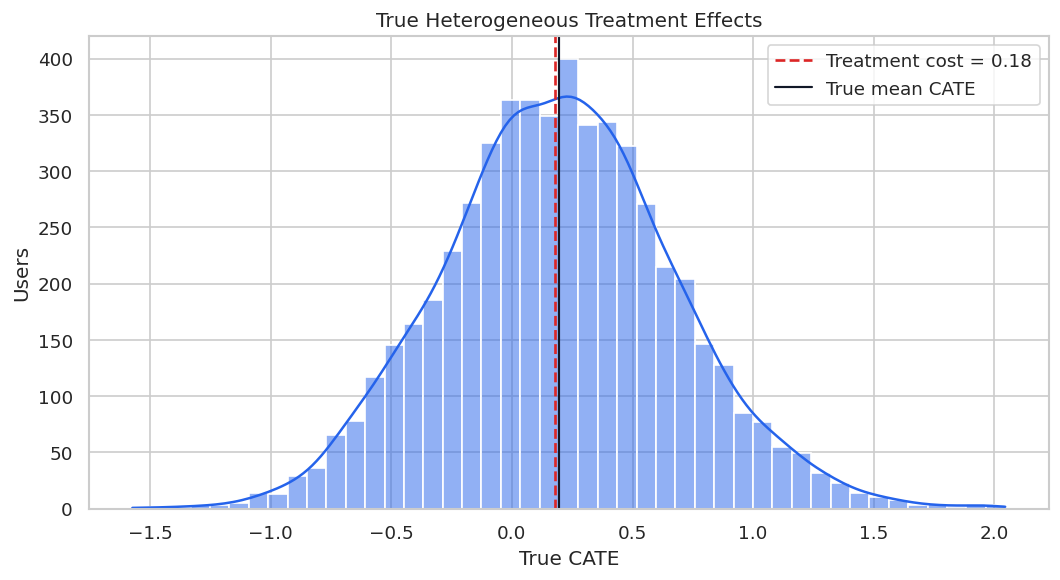

,true_cate
count,"5,500.0000"
mean,0.1958
std,0.4820
min,-1.5732
5%,-0.5931
25%,-0.1223
50%,0.1933
75%,0.5051
95%,1.0103
max,2.0447


In [7]:
true_effect_summary = users["true_cate"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("true_cate")
true_effect_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_true_effect_summary.csv")
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(users["true_cate"], bins=45, kde=True, color="#2563eb", ax=ax)
ax.axvline(TREATMENT_COST, color="#dc2626", linestyle="--", linewidth=1.6, label=f"Treatment cost = {TREATMENT_COST:.2f}")
ax.axvline(users["true_cate"].mean(), color="#111827", linewidth=1.3, label="True mean CATE")
ax.set_title("True Heterogeneous Treatment Effects")
ax.set_xlabel("True CATE")
ax.set_ylabel("Users")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_true_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()
display(true_effect_summary)


The distribution has meaningful spread around the average. Some users are much more attractive to target than others once cost is considered.

The decision implication is that estimated gains need to be filtered through uncertainty, cost, support, and operational constraints before becoming actions.
<!-- result-implication-expanded -->


### Covariate Balance Before Adjustment

Standardized mean differences compare treated and control groups on pre-treatment variables. Large absolute values indicate that treatment assignment is related to user characteristics.


In [8]:
OBSERVED_FEATURES = [
    "onboarding_gap", "prior_sessions", "content_diversity", "search_difficulty", "support_contacts",
    "price_sensitivity", "device_reliability", "high_motivation_segment", "tenure_weeks",
    "region_competition", "market_maturity", "marketing_pressure", "account_complexity",
    "referral_organic", "weekday_signup", "mobile_primary",
]
balance_rows = []
for feature in OBSERVED_FEATURES:
    treated = users.loc[users["onboarding_bundle"] == 1, feature]
    control = users.loc[users["onboarding_bundle"] == 0, feature]
    pooled_sd = np.sqrt((treated.var(skipna=True) + control.var(skipna=True)) / 2)
    smd = (treated.mean(skipna=True) - control.mean(skipna=True)) / pooled_sd if pooled_sd > 0 else 0.0
    balance_rows.append(
        {
            "feature": feature,
            "treated_mean": treated.mean(skipna=True),
            "control_mean": control.mean(skipna=True),
            "standardized_mean_difference": smd,
            "abs_smd": abs(smd),
        }
    )
balance_table = pd.DataFrame(balance_rows).sort_values("abs_smd", ascending=False)
balance_table.to_csv(TABLE_DIR / f"{CASE_PREFIX}_covariate_balance.csv", index=False)
display(balance_table.head(12))


,feature,treated_mean,control_mean,standardized_mean_difference,abs_smd
0,onboarding_gap,0.2406,-0.2843,0.5503,0.5503
1,prior_sessions,0.2548,-0.2455,0.5121,0.5121
2,content_diversity,0.2235,-0.2174,0.4537,0.4537
3,search_difficulty,0.1248,-0.1917,0.3176,0.3176
7,high_motivation_segment,0.5651,0.4406,0.2508,0.2508
5,price_sensitivity,0.1005,-0.1055,0.2071,0.2071
11,marketing_pressure,0.1125,-0.0906,0.2062,0.2062
4,support_contacts,1.2205,1.0035,0.2036,0.2036
6,device_reliability,0.0726,-0.0835,0.1549,0.1549
14,weekday_signup,0.7087,0.7356,-0.0603,0.0603


The largest imbalances identify why the raw comparison is risky. Several variables that influence treatment also influence outcomes.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->


#### Balance Plot

The balance plot makes imbalance easier to scan. Dashed reference lines at `+0.10` and `-0.10` mark a common practical threshold for variables worth investigating.


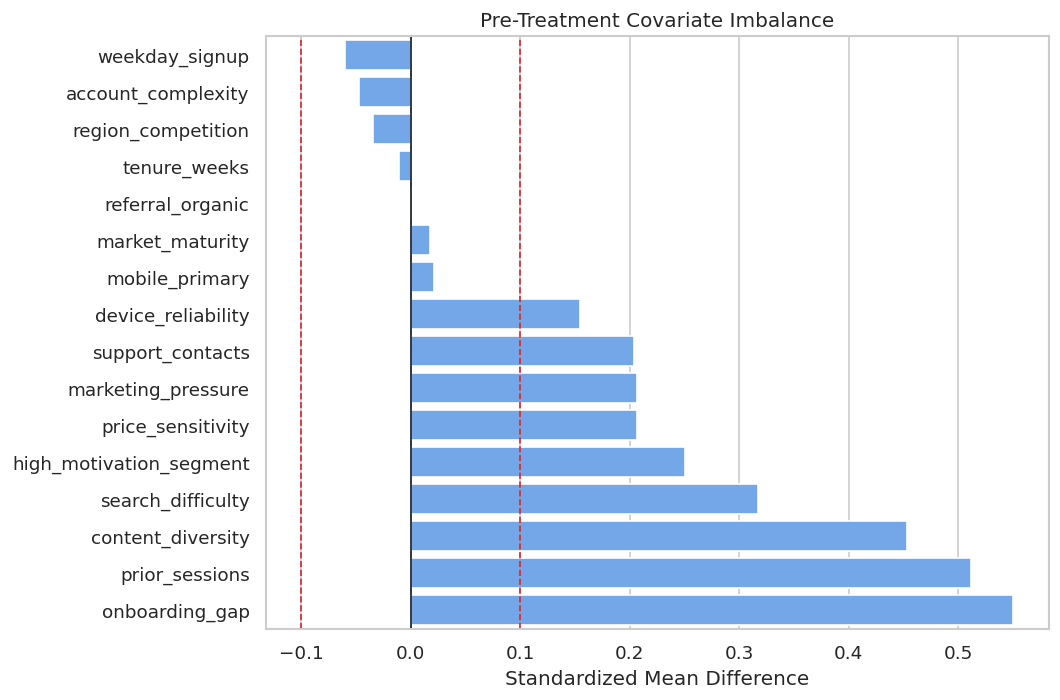

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_balance = balance_table.sort_values("standardized_mean_difference")
sns.barplot(data=plot_balance, x="standardized_mean_difference", y="feature", color="#60a5fa", ax=ax)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#dc2626", linestyle="--", linewidth=1)
ax.axvline(-0.10, color="#dc2626", linestyle="--", linewidth=1)
ax.set_title("Pre-Treatment Covariate Imbalance")
ax.set_xlabel("Standardized Mean Difference")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()


The imbalance pattern is exactly what motivates causal adjustment. The assignment rule has targeted users with different pre-treatment profiles.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Propensity Overlap Diagnostic

Overlap means similar users can be observed both treated and untreated. If estimated propensity scores are extremely close to zero or one, CATE estimates become more dependent on extrapolation.


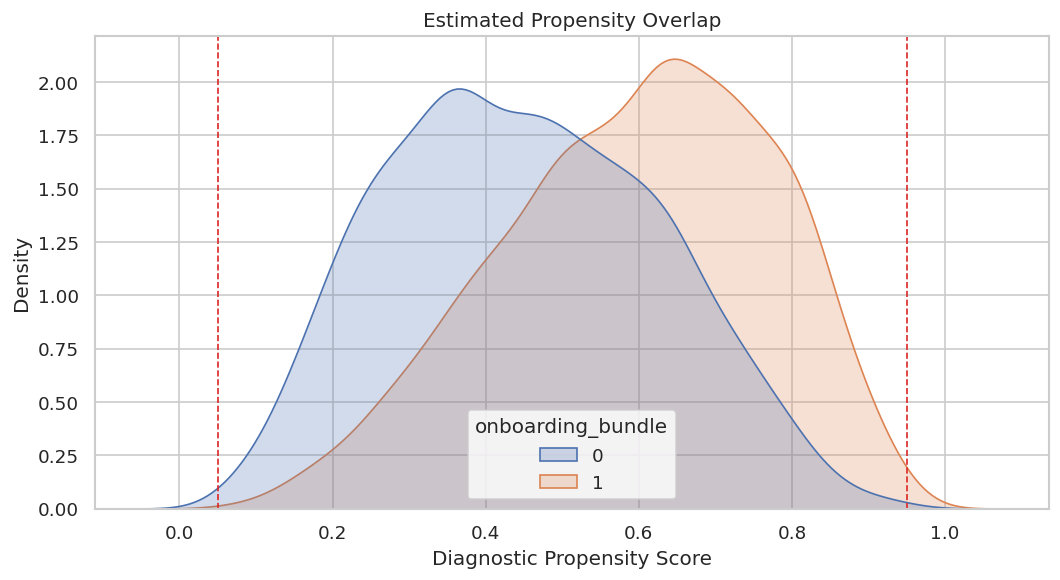

,diagnostic_propensity
count,"5,500.0000"
mean,0.5255
std,0.1915
min,0.0563
1%,0.1259
5%,0.2071
10%,0.2619
50%,0.5312
90%,0.7811
95%,0.8259


In [10]:
propensity_frame = users[OBSERVED_FEATURES].fillna(users[OBSERVED_FEATURES].median())
diagnostic_propensity_model = LogisticRegression(max_iter=1_000, solver="lbfgs")
diagnostic_propensity_model.fit(propensity_frame, users["onboarding_bundle"])
users["diagnostic_propensity"] = diagnostic_propensity_model.predict_proba(propensity_frame)[:, 1]
propensity_summary = users["diagnostic_propensity"].describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]).to_frame("diagnostic_propensity")
propensity_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_diagnostic_propensity_summary.csv")
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=users, x="diagnostic_propensity", hue="onboarding_bundle", common_norm=False, fill=True, alpha=0.25, ax=ax)
ax.axvline(0.05, color="#dc2626", linestyle="--", linewidth=1)
ax.axvline(0.95, color="#dc2626", linestyle="--", linewidth=1)
ax.set_title("Estimated Propensity Overlap")
ax.set_xlabel("Diagnostic Propensity Score")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_diagnostic_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()
display(propensity_summary)


Overlap is usable but not perfect. That means the analysis can proceed, while later recommendations should still be cautious around extreme-propensity users.

For causal interpretation, this support check shows when weak overlap may force an estimator to extrapolate beyond comparable treated and control units.
<!-- result-implication-expanded -->




#### Train-Test Split

The estimators are fit on the training set and evaluated on a held-out set. Stratifying by treatment keeps the treated/control share similar in both samples.


In [11]:
train_df, test_df = train_test_split(
    users,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=users["onboarding_bundle"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "treatment_rate": [train_df["onboarding_bundle"].mean(), test_df["onboarding_bundle"].mean()],
        "mean_outcome": [train_df["eight_week_value"].mean(), test_df["eight_week_value"].mean()],
        "mean_true_cate": [train_df["true_cate"].mean(), test_df["true_cate"].mean()],
    }
)
split_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_train_test_split_summary.csv", index=False)
display(split_summary)


,split,rows,treatment_rate,mean_outcome,mean_true_cate
0,train,3850,0.5255,1.3454,0.2020
1,test,1650,0.5255,1.3194,0.1812


The splits are comparable in size, treatment rate, and average true effect. That creates a stable evaluation setup for the rest of the lesson.


### Feature Roles for EconML

`X` contains effect modifiers: variables we want the CATE function to vary with and variables a targeting rule may use. `W` contains additional controls used for adjustment in nuisance models.


In [12]:
X_COLUMNS = [
    "onboarding_gap", "prior_sessions", "content_diversity", "search_difficulty",
    "support_contacts", "price_sensitivity", "device_reliability", "high_motivation_segment",
]
W_COLUMNS = [
    "tenure_weeks", "region_competition", "market_maturity", "marketing_pressure",
    "account_complexity", "referral_organic", "weekday_signup", "mobile_primary",
]
feature_role_table = pd.DataFrame(
    {
        "field": X_COLUMNS + W_COLUMNS,
        "econml_role": ["X"] * len(X_COLUMNS) + ["W"] * len(W_COLUMNS),
    }
)
feature_role_table["reason"] = [
    "May directly change how much help onboarding provides.",
    "Early activity can modify treatment value.",
    "Breadth of interests can make guided discovery more useful.",
    "Search difficulty is a clear need signal.",
    "Support burden may limit incremental benefit.",
    "Cost concerns can reduce realized impact.",
    "Technical reliability can enable or block benefit.",
    "Motivation segment is an actionable effect modifier.",
    "Account age adjusts for maturity at decision time.",
    "Market competition affects both assignment and outcome.",
    "Market maturity adjusts for environment quality.",
    "Other marketing pressure can confound outcomes.",
    "Operational complexity adjusts for baseline value.",
    "Acquisition source can confound early engagement.",
    "Signup day controls timing patterns.",
    "Primary device controls experience differences.",
]
feature_role_table.to_csv(TABLE_DIR / f"{CASE_PREFIX}_feature_role_table.csv", index=False)
display(feature_role_table)


,field,econml_role,reason
0,onboarding_gap,X,May directly change how much help onboarding provides.
1,prior_sessions,X,Early activity can modify treatment value.
2,content_diversity,X,Breadth of interests can make guided discovery more useful.
3,search_difficulty,X,Search difficulty is a clear need signal.
4,support_contacts,X,Support burden may limit incremental benefit.
5,price_sensitivity,X,Cost concerns can reduce realized impact.
6,device_reliability,X,Technical reliability can enable or block benefit.
7,high_motivation_segment,X,Motivation segment is an actionable effect modifier.
8,tenure_weeks,W,Account age adjusts for maturity at decision time.
9,region_competition,W,Market competition affects both assignment and outcome.


This split keeps the CATE surface focused on user-need and product-experience fields. The controls still adjust for confounding, but they are not the main segmentation story.


#### Train-Only Imputation and Matrix Construction

Missing values are imputed using training medians only. Missingness flags are placed in `W`, allowing nuisance models to learn whether missingness itself is predictive without making the CATE surface harder to explain.


In [13]:
# Define reusable helpers for the Train-Only Imputation And Matrix Construction section.
ALL_MODEL_COLUMNS = X_COLUMNS + W_COLUMNS
train_medians = train_df[ALL_MODEL_COLUMNS].median(numeric_only=True)
MISSING_FLAG_COLUMNS = [column for column in ALL_MODEL_COLUMNS if train_df[column].isna().any() or test_df[column].isna().any()]
def build_design_matrices(frame, medians):
    """
    Idea: Build the design matrices representation used by the Train-Only Imputation And Matrix Construction analysis.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    medians : object
        Context-specific input used for medians in this helper.
    
    Returns
    -------
    tuple
        Tuple containing X, W, aligned for the causal estimator.
    """
    raw_features = frame[ALL_MODEL_COLUMNS].copy()
    missing_flags = raw_features[MISSING_FLAG_COLUMNS].isna().astype(float).add_suffix("_missing")
    filled_features = raw_features.fillna(medians)
    X = filled_features[X_COLUMNS].astype(float)
    W = pd.concat([filled_features[W_COLUMNS].astype(float), missing_flags], axis=1)
    return X, W
X_train, W_train = build_design_matrices(train_df, train_medians)
X_test, W_test = build_design_matrices(test_df, train_medians)
T_train = train_df["onboarding_bundle"].astype(int)
T_test = test_df["onboarding_bundle"].astype(int)
Y_train = train_df["eight_week_value"].astype(float)
Y_test = test_df["eight_week_value"].astype(float)
true_tau_test = test_df["true_cate"].to_numpy()
matrix_summary = pd.DataFrame(
    {
        "matrix": ["X_train", "W_train", "X_test", "W_test"],
        "rows": [X_train.shape[0], W_train.shape[0], X_test.shape[0], W_test.shape[0]],
        "columns": [X_train.shape[1], W_train.shape[1], X_test.shape[1], W_test.shape[1]],
        "missing_values_after_preparation": [
            int(X_train.isna().sum().sum()), int(W_train.isna().sum().sum()),
            int(X_test.isna().sum().sum()), int(W_test.isna().sum().sum()),
        ],
    }
)
matrix_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_model_matrix_summary.csv", index=False)
display(matrix_summary)


,matrix,rows,columns,missing_values_after_preparation
0,X_train,3850,8,0
1,W_train,3850,12,0
2,X_test,1650,8,0
3,W_test,1650,12,0


The prepared matrices contain no missing values. The key practice is that test rows did not influence the imputation values used for training.

The decision implication is that estimated gains need to be filtered through uncertainty, cost, support, and operational constraints before becoming actions.
<!-- result-implication-expanded -->




### Nuisance Model Diagnostics

Treatment-effect estimators rely on nuisance models for treatment assignment and outcomes. These diagnostics check whether observed pre-treatment features contain enough predictive signal to support adjustment.


In [14]:
# Define reusable helpers for the Nuisance Model Diagnostics section.
def make_rf_classifier(seed_offset=0):
    """
    Idea: Construct the random-forest classifier used in the Nuisance Model Diagnostics section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    seed_offset : object
        Offset added to the base random seed for a reproducible scenario variant.
    
    Returns
    -------
    RandomForestClassifier
        Configured random-forest classifier used as a nuisance propensity or treatment model.
    """
    return RandomForestClassifier(
        n_estimators=180,
        min_samples_leaf=30,
        max_features=0.75,
        random_state=RANDOM_STATE + seed_offset,
        n_jobs=-1,
    )
def make_rf_regressor(seed_offset=0):
    """
    Idea: Construct the random-forest regressor used in the Nuisance Model Diagnostics section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    seed_offset : object
        Offset added to the base random seed for a reproducible scenario variant.
    
    Returns
    -------
    RandomForestRegressor
        Configured random-forest regressor used as an outcome or final-stage model.
    """
    return RandomForestRegressor(
        n_estimators=180,
        min_samples_leaf=25,
        max_features=0.75,
        random_state=RANDOM_STATE + seed_offset,
        n_jobs=-1,
    )
XW_train = pd.concat([X_train, W_train], axis=1)
XW_test = pd.concat([X_test, W_test], axis=1)
propensity_model = make_rf_classifier(10)
propensity_model.fit(XW_train, T_train)
propensity_pred = np.clip(propensity_model.predict_proba(XW_test)[:, 1], 1e-4, 1 - 1e-4)
outcome_model_control = make_rf_regressor(20)
outcome_model_treated = make_rf_regressor(30)
outcome_model_control.fit(XW_train.loc[T_train == 0], Y_train.loc[T_train == 0])
outcome_model_treated.fit(XW_train.loc[T_train == 1], Y_train.loc[T_train == 1])
mu0_pred = outcome_model_control.predict(XW_test)
mu1_pred = outcome_model_treated.predict(XW_test)
outcome_pred_observed_arm = np.where(T_test.to_numpy() == 1, mu1_pred, mu0_pred)
nuisance_diagnostics = pd.DataFrame(
    {
        "diagnostic": [
            "propensity_auc", "propensity_log_loss", "propensity_min", "propensity_max",
            "outcome_observed_arm_r2", "outcome_observed_arm_mae",
        ],
        "value": [
            roc_auc_score(T_test, propensity_pred), log_loss(T_test, propensity_pred),
            propensity_pred.min(), propensity_pred.max(),
            r2_score(Y_test, outcome_pred_observed_arm), mean_absolute_error(Y_test, outcome_pred_observed_arm),
        ],
    }
)
nuisance_diagnostics.to_csv(TABLE_DIR / f"{CASE_PREFIX}_nuisance_diagnostics.csv", index=False)
display(nuisance_diagnostics)


,diagnostic,value
0,propensity_auc,0.7218
1,propensity_log_loss,0.6137
2,propensity_min,0.1216
3,propensity_max,0.9082
4,outcome_observed_arm_r2,0.5002
5,outcome_observed_arm_mae,0.6858


The treatment model has signal, confirming that treatment was targeted. The outcome model is also informative enough to proceed, though it remains an approximation.


#### Overlap Buckets on the Held-Out Sample

Bucketed propensities reveal where support is strong or weak. The later policy section will use these scores to create a conservative support-aware targeting rule.


In [15]:
overlap_frame = test_df[["user_id", "onboarding_bundle", "eight_week_value", "true_cate"]].copy()
overlap_frame["estimated_propensity"] = propensity_pred
overlap_frame["overlap_bucket"] = pd.cut(
    overlap_frame["estimated_propensity"],
    bins=[0.0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0],
    include_lowest=True,
)
overlap_summary = (
    overlap_frame.groupby("overlap_bucket", observed=True)
    .agg(
        users=("user_id", "size"),
        treatment_rate=("onboarding_bundle", "mean"),
        mean_true_cate=("true_cate", "mean"),
        mean_outcome=("eight_week_value", "mean"),
    )
    .reset_index()
)
overlap_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_overlap_bucket_summary.csv", index=False)
display(overlap_summary)


,overlap_bucket,users,treatment_rate,mean_true_cate,mean_outcome
0,"(0.1, 0.25]",98,0.2347,-0.2653,0.3108
1,"(0.25, 0.5]",647,0.3787,-0.0381,0.9534
2,"(0.5, 0.75]",724,0.6105,0.3050,1.5611
3,"(0.75, 0.9]",179,0.8659,0.7032,2.1917
4,"(0.9, 1.0]",2,1.0000,1.4372,3.5733


Most users sit away from the most extreme propensity regions. That is encouraging, but the edge buckets are still useful for cautious reporting.

For causal interpretation, this support check shows when weak overlap may force an estimator to extrapolate beyond comparable treated and control units.
<!-- result-implication-expanded -->




#### Estimator Strategy

The case study uses three complementary EconML estimators to test whether the recommendation is stable across reasonable modeling choices.


| estimator | main_strength | main_risk | why_used_here |
| --- | --- | --- | --- |
| LinearDML | Transparent structured heterogeneity with polynomial features. | Can miss sharp nonlinearities. | Readable baseline. |
| CausalForestDML | Flexible nonlinear heterogeneity. | Can be noisier and slower. | Matches the nonlinear teaching setup. |
| DRLearner | Doubly robust pseudo-outcome strategy. | Can inherit variance from propensity estimates. | Useful for robust targeting comparison. |


The table names the modeling tradeoff before results are known. That keeps the comparison from becoming pure scoreboard chasing.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->


#### Fit EconML Estimators

The code below fits all estimators on the same training matrices and records runtime. The treatment is binary, so the DML estimators are configured for discrete treatment where needed.


In [16]:
# Fit or evaluate the model objects used in the Fit EconML Estimators section.
estimators = {
    "LinearDML": LinearDML(
        model_y=make_rf_regressor(101),
        model_t=make_rf_classifier(102),
        discrete_treatment=True,
        featurizer=PolynomialFeatures(degree=2, include_bias=False),
        cv=3,
        random_state=RANDOM_STATE,
    ),
    "CausalForestDML": CausalForestDML(
        model_y=make_rf_regressor(201),
        model_t=make_rf_classifier(202),
        discrete_treatment=True,
        n_estimators=160,
        min_samples_leaf=18,
        max_samples=0.45,
        cv=3,
        random_state=RANDOM_STATE,
    ),
    "DRLearner": DRLearner(
        model_propensity=make_rf_classifier(301),
        model_regression=make_rf_regressor(302),
        model_final=make_rf_regressor(303),
        min_propensity=0.02,
        cv=3,
        random_state=RANDOM_STATE,
    ),
}
fit_rows = []
for estimator_name, estimator in estimators.items():
    start = time.perf_counter()
    estimator.fit(Y_train, T_train, X=X_train, W=W_train)
    fit_rows.append({"estimator": estimator_name, "fit_seconds": time.perf_counter() - start})
fit_runtime = pd.DataFrame(fit_rows).sort_values("fit_seconds")
fit_runtime.to_csv(TABLE_DIR / f"{CASE_PREFIX}_fit_runtime.csv", index=False)
display(fit_runtime)


,estimator,fit_seconds
0,LinearDML,3.0391
2,DRLearner,3.5732
1,CausalForestDML,3.6302


Runtime is part of practical model selection. A small accuracy improvement may not be worth much if it makes the workflow harder to refresh or explain.


### Predict Held-Out CATEs

Each estimator now predicts a treatment effect for each held-out user. The true CATE is attached only for evaluation.


In [17]:
effect_predictions = test_df[["user_id", "onboarding_bundle", "eight_week_value", "true_cate", "diagnostic_propensity"]].copy()
prediction_rows = []
for estimator_name, estimator in estimators.items():
    start = time.perf_counter()
    effect_predictions[estimator_name] = estimator.effect(X_test)
    prediction_rows.append({"estimator": estimator_name, "predict_seconds": time.perf_counter() - start})
prediction_runtime = pd.DataFrame(prediction_rows).sort_values("predict_seconds")
effect_predictions.to_csv(TABLE_DIR / f"{CASE_PREFIX}_heldout_effect_predictions.csv", index=False)
prediction_runtime.to_csv(TABLE_DIR / f"{CASE_PREFIX}_prediction_runtime.csv", index=False)
display(effect_predictions.head())
display(prediction_runtime)


,user_id,onboarding_bundle,eight_week_value,true_cate,diagnostic_propensity,LinearDML,CausalForestDML,DRLearner
0,5064,1,2.0690,0.1123,0.5733,0.1962,0.0582,0.2281
1,1117,1,1.0561,0.1787,0.6108,0.0079,0.1102,0.0641
2,3396,0,1.8315,-0.2375,0.2277,-0.0012,0.0042,-0.1578
3,1511,1,1.4275,0.5047,0.7575,0.7616,0.3912,0.6287
4,5101,1,1.4083,-0.4018,0.7290,-0.1236,0.2198,0.3812


,estimator,predict_seconds
0,LinearDML,0.0053
1,CausalForestDML,0.0638
2,DRLearner,0.0737


The prediction table is the bridge from estimation to action. Once every held-out user has an estimated incremental effect, we can evaluate accuracy, ranking, segments, and policy value.




#### Held-Out Benchmark Metrics

The benchmark compares estimators using average-effect bias, individual-effect error, correlation with the true effect ranking, top-segment value, and treatment share above cost.


In [18]:
# Define reusable helpers for the Held-Out Benchmark Metrics section.
def safe_corr(left, right):
    """
    Idea: Compute a correlation only when both inputs contain enough variation to make the result meaningful.
    
    Parameters
    ----------
    left : object
        Left-side value, node, or coordinate in a comparison.
    right : object
        Right-side value, node, or coordinate in a comparison.
    
    Returns
    -------
    float
        Pearson correlation, or NaN when either input has too little variation.
    """
    if np.std(left) == 0 or np.std(right) == 0:
        return np.nan
    return float(np.corrcoef(left, right)[0, 1])
benchmark_rows = []
true_ate_test = true_tau_test.mean()
for estimator_name in estimators:
    estimated = effect_predictions[estimator_name].to_numpy()
    top_mask = estimated >= np.quantile(estimated, 0.80)
    benchmark_rows.append(
        {
            "estimator": estimator_name,
            "true_ate_test": true_ate_test,
            "estimated_ate": estimated.mean(),
            "ate_bias": estimated.mean() - true_ate_test,
            "abs_ate_bias": abs(estimated.mean() - true_ate_test),
            "cate_rmse": mean_squared_error(true_tau_test, estimated) ** 0.5,
            "cate_mae": mean_absolute_error(true_tau_test, estimated),
            "cate_correlation": safe_corr(true_tau_test, estimated),
            "top_20_true_cate_mean": true_tau_test[top_mask].mean(),
            "top_20_estimated_cate_mean": estimated[top_mask].mean(),
            "share_estimated_above_cost": np.mean(estimated > TREATMENT_COST),
        }
    )
benchmark_metrics = pd.DataFrame(benchmark_rows).merge(fit_runtime, on="estimator").merge(prediction_runtime, on="estimator")
benchmark_metrics = benchmark_metrics.sort_values("cate_rmse")
benchmark_metrics.to_csv(TABLE_DIR / f"{CASE_PREFIX}_benchmark_metrics.csv", index=False)
display(benchmark_metrics)


,estimator,true_ate_test,estimated_ate,ate_bias,abs_ate_bias,cate_rmse,cate_mae,cate_correlation,top_20_true_cate_mean,top_20_estimated_cate_mean,share_estimated_above_cost,fit_seconds,predict_seconds
0,LinearDML,0.1812,0.2309,0.0497,0.0497,0.2719,0.2085,0.8948,0.7908,1.0499,0.5394,3.0391,0.0053
2,DRLearner,0.1812,0.2099,0.0287,0.0287,0.2720,0.2129,0.8458,0.7515,0.9236,0.5188,3.5732,0.0737
1,CausalForestDML,0.1812,0.2147,0.0336,0.0336,0.3168,0.2404,0.8173,0.7613,0.5643,0.5558,3.6302,0.0638


The best estimator depends on the use case. For targeting, ranking quality and top-segment value can matter more than a tiny difference in average-effect bias.




#### Accuracy and Bias Plot

The next figure compares CATE RMSE with absolute ATE bias. This catches models that estimate the average well but miss heterogeneous effects.


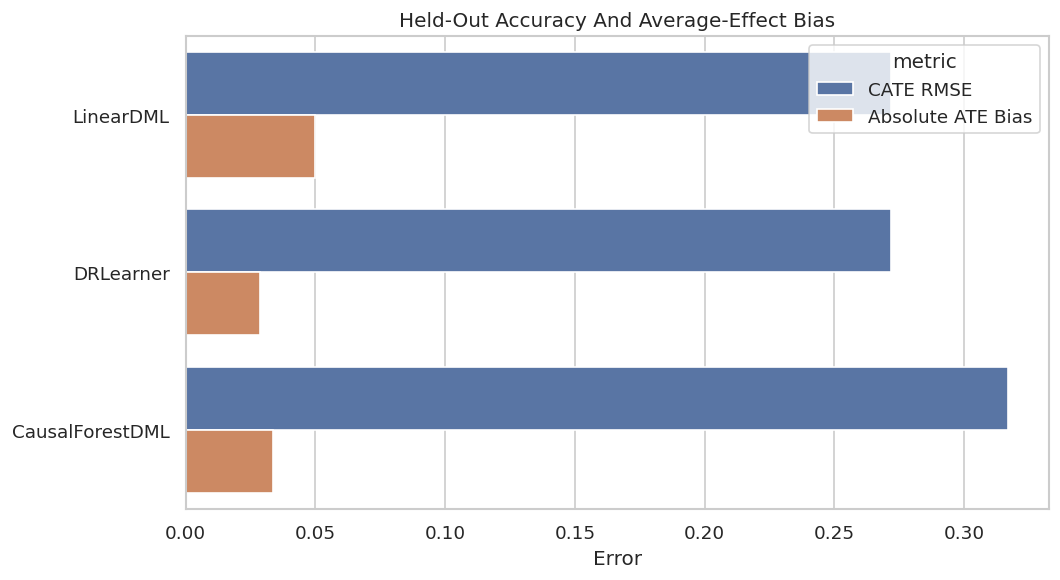

In [19]:
metric_plot = benchmark_metrics.melt(
    id_vars="estimator",
    value_vars=["cate_rmse", "abs_ate_bias"],
    var_name="metric",
    value_name="value",
)
metric_plot["metric"] = metric_plot["metric"].map({"cate_rmse": "CATE RMSE", "abs_ate_bias": "Absolute ATE Bias"})
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=metric_plot, x="value", y="estimator", hue="metric", ax=ax)
ax.set_title("Held-Out Accuracy And Average-Effect Bias")
ax.set_xlabel("Error")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_accuracy_and_bias.png", dpi=160, bbox_inches="tight")
plt.show()


This plot makes the accuracy tradeoff visible. In real work, true CATE would be unavailable, so analogous validation would rely on experiments, temporal checks, or sensitivity analysis.




#### CATE Recovery Scatterplots

Scatterplots show whether estimated effects recover the shape of the true effect surface. Points near the diagonal are closer to the known truth.


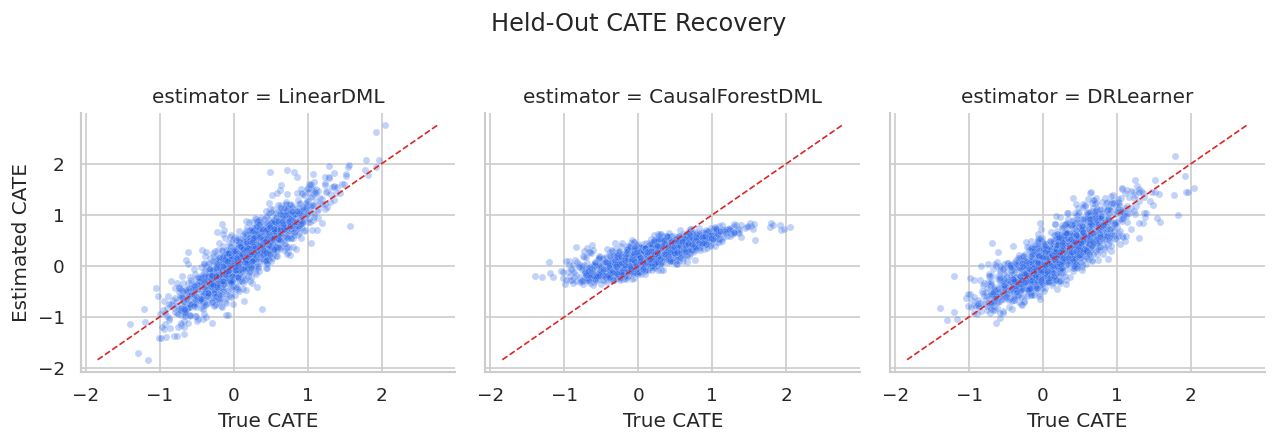

In [20]:
scatter_data = effect_predictions.melt(
    id_vars=["user_id", "true_cate"],
    value_vars=list(estimators.keys()),
    var_name="estimator",
    value_name="estimated_cate",
)
min_value = min(scatter_data["true_cate"].min(), scatter_data["estimated_cate"].min())
max_value = max(scatter_data["true_cate"].max(), scatter_data["estimated_cate"].max())
g = sns.FacetGrid(scatter_data, col="estimator", col_wrap=3, height=3.6, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="true_cate", y="estimated_cate", alpha=0.28, s=18, color="#2563eb")
for ax in g.axes.flat:
    ax.plot([min_value, max_value], [min_value, max_value], color="#dc2626", linestyle="--", linewidth=1)
    ax.set_xlabel("True CATE")
    ax.set_ylabel("Estimated CATE")
g.fig.suptitle("Held-Out CATE Recovery", y=1.02)
plt.tight_layout()
g.fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_cate_recovery_scatterplots.png", dpi=160, bbox_inches="tight")
plt.show()


The scatterplots show whether estimates are simply compressed toward the mean or whether they separate high- and low-benefit users.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Decile Calibration

Calibration asks whether users placed into higher estimated-effect buckets also have higher true effects. This is a practical targeting diagnostic.


In [21]:
calibration_parts = []
for estimator_name in estimators:
    temp = effect_predictions[["user_id", "true_cate", estimator_name]].copy()
    temp["estimated_cate"] = temp[estimator_name]
    temp["estimated_decile"] = pd.qcut(temp["estimated_cate"], q=10, labels=False, duplicates="drop") + 1
    summary = (
        temp.groupby("estimated_decile", observed=True)
        .agg(
            users=("user_id", "size"),
            mean_estimated_cate=("estimated_cate", "mean"),
            mean_true_cate=("true_cate", "mean"),
        )
        .reset_index()
    )
    summary["estimator"] = estimator_name
    calibration_parts.append(summary)
calibration_table = pd.concat(calibration_parts, ignore_index=True)
calibration_table.to_csv(TABLE_DIR / f"{CASE_PREFIX}_decile_calibration.csv", index=False)
display(calibration_table.head(15))


,estimated_decile,users,mean_estimated_cate,mean_true_cate,estimator
0,1,165,-0.8145,-0.5506,LinearDML
1,2,165,-0.3783,-0.2866,LinearDML
2,3,165,-0.1381,-0.1077,LinearDML
3,4,165,0.0292,0.0188,LinearDML
4,5,165,0.1672,0.1223,LinearDML
5,6,165,0.2903,0.2248,LinearDML
6,7,165,0.4427,0.3436,LinearDML
7,8,165,0.6106,0.4654,LinearDML
8,9,165,0.8049,0.6159,LinearDML
9,10,165,1.2949,0.9657,LinearDML


A useful targeting model should show rising true effects as estimated deciles increase. If that pattern fails, individual targeting is hard to justify.

The decision implication is that estimated gains need to be filtered through uncertainty, cost, support, and operational constraints before becoming actions.
<!-- result-implication-expanded -->


#### Calibration Plot

The plot compares estimated and true average CATE by estimated-effect decile for each estimator.


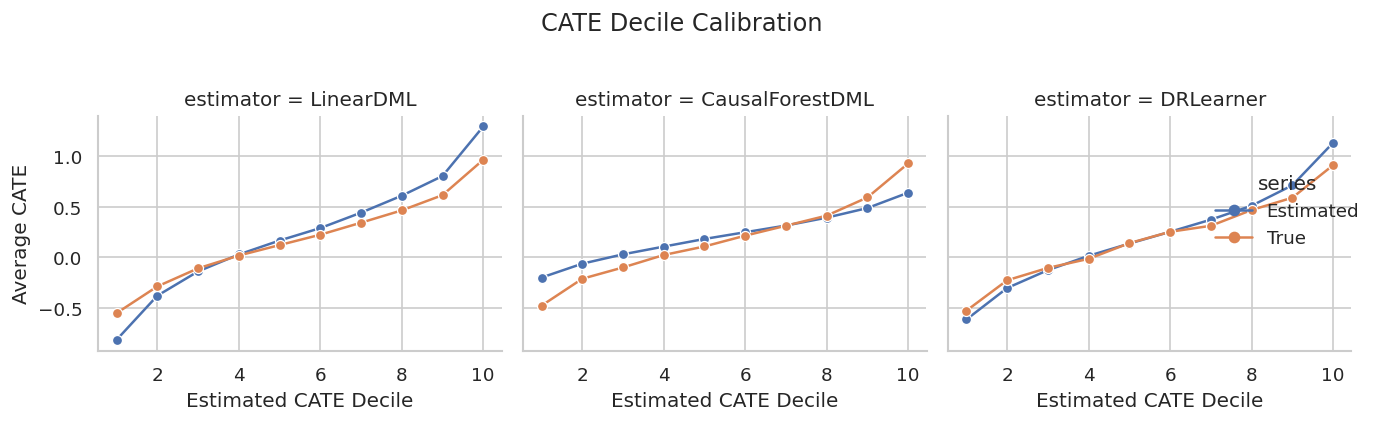

In [22]:
calibration_plot = calibration_table.melt(
    id_vars=["estimator", "estimated_decile", "users"],
    value_vars=["mean_estimated_cate", "mean_true_cate"],
    var_name="series",
    value_name="cate",
)
calibration_plot["series"] = calibration_plot["series"].map({"mean_estimated_cate": "Estimated", "mean_true_cate": "True"})
g = sns.relplot(
    data=calibration_plot,
    x="estimated_decile",
    y="cate",
    hue="series",
    col="estimator",
    kind="line",
    marker="o",
    col_wrap=3,
    height=3.4,
    facet_kws={"sharey": True},
)
g.set_axis_labels("Estimated CATE Decile", "Average CATE")
g.fig.suptitle("CATE Decile Calibration", y=1.03)
plt.tight_layout()
g.fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_decile_calibration.png", dpi=160, bbox_inches="tight")
plt.show()


This view is decision-oriented. A model can be noisy at the individual level yet still useful if it ranks high-benefit users reliably.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->




#### Segment-Level Checks

Segment checks reveal whether estimator behavior is stable across meaningful groups. This catches cases where a model looks good overall but fails in a segment that matters.


In [23]:
segment_definitions = {
    "high_onboarding_gap": test_df["onboarding_gap"] >= test_df["onboarding_gap"].median(),
    "high_prior_sessions": test_df["prior_sessions"] >= test_df["prior_sessions"].median(),
    "high_search_difficulty": test_df["search_difficulty"].fillna(train_medians["search_difficulty"]) >= test_df["search_difficulty"].fillna(train_medians["search_difficulty"]).median(),
    "high_price_sensitivity": test_df["price_sensitivity"] >= test_df["price_sensitivity"].median(),
    "high_motivation_segment": test_df["high_motivation_segment"] == 1,
    "organic_referral": test_df["referral_organic"] == 1,
    "mobile_primary": test_df["mobile_primary"] == 1,
}
segment_rows = []
for segment_name, mask in segment_definitions.items():
    mask_array = mask.to_numpy()
    for estimator_name in estimators:
        estimated = effect_predictions[estimator_name].to_numpy()
        segment_rows.append(
            {
                "segment": segment_name,
                "estimator": estimator_name,
                "users": int(mask_array.sum()),
                "true_cate_mean": true_tau_test[mask_array].mean(),
                "estimated_cate_mean": estimated[mask_array].mean(),
                "segment_bias": estimated[mask_array].mean() - true_tau_test[mask_array].mean(),
                "share_estimated_above_cost": np.mean(estimated[mask_array] > TREATMENT_COST),
            }
        )
segment_benchmark = pd.DataFrame(segment_rows)
segment_benchmark.to_csv(TABLE_DIR / f"{CASE_PREFIX}_segment_benchmark.csv", index=False)
display(segment_benchmark.head(15))


,segment,estimator,users,true_cate_mean,estimated_cate_mean,segment_bias,share_estimated_above_cost
0,high_onboarding_gap,LinearDML,825,0.4101,0.5078,0.0977,0.7527
1,high_onboarding_gap,CausalForestDML,825,0.4101,0.3854,-0.0247,0.8800
2,high_onboarding_gap,DRLearner,825,0.4101,0.4808,0.0707,0.7564
3,high_prior_sessions,LinearDML,825,0.2634,0.2984,0.0350,0.5927
4,high_prior_sessions,CausalForestDML,825,0.2634,0.2665,0.0031,0.6461
5,high_prior_sessions,DRLearner,825,0.2634,0.2666,0.0031,0.5697
6,high_search_difficulty,LinearDML,825,0.2798,0.3400,0.0602,0.6085
7,high_search_difficulty,CausalForestDML,825,0.2798,0.2913,0.0115,0.6812
8,high_search_difficulty,DRLearner,825,0.2798,0.3170,0.0372,0.6048
9,high_price_sensitivity,LinearDML,825,0.1520,0.1980,0.0460,0.5139


Segment summaries show where estimated effects are systematically high or low. In real analysis, this would be a stability check that supports the final recommendation.


#### Segment Bias Heatmap

The heatmap makes segment-level average bias easy to scan across estimators.


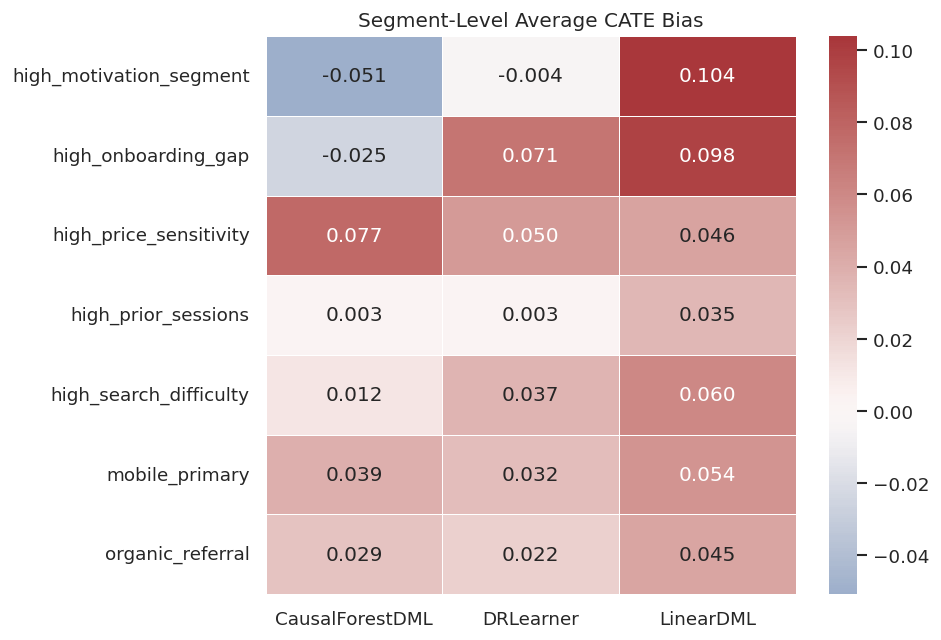

In [24]:
segment_heatmap = segment_benchmark.pivot(index="segment", columns="estimator", values="segment_bias")
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(segment_heatmap, annot=True, fmt=".3f", cmap="vlag", center=0, linewidths=0.5, ax=ax)
ax.set_title("Segment-Level Average CATE Bias")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_segment_bias_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


The heatmap separates global accuracy from segment reliability. A strong recommendation should mention both.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




#### Cost-Aware Policy Targeting

The simplest policy treats a user when estimated CATE is greater than treatment cost. We compare that with two baselines: treat nobody and treat everybody.


In [25]:
# Define reusable helpers for the Cost-Aware Policy Targeting section.
def summarize_policy(policy_name, action, estimated_effect=None):
    """
    Idea: Summarize the policy into a compact table for interpretation in the Cost-Aware Policy Targeting section.
    
    Parameters
    ----------
    policy_name : object
        Readable label used in tables and plots.
    action : object
        Treatment or decision action evaluated by the policy rule.
    estimated_effect : object
        Numeric target or oracle value used for comparison.
    
    Returns
    -------
    dict[str, float]
        Policy summary with treatment rate, users treated, true net value, precision among treated users, and CATE averages.
    """
    action = action.astype(int)
    true_net = (true_tau_test - TREATMENT_COST) * action
    return {
        "policy": policy_name,
        "treatment_rate": action.mean(),
        "users_treated": int(action.sum()),
        "true_net_value_per_user": true_net.mean(),
        "true_gross_effect_per_user": (true_tau_test * action).mean(),
        "precision_positive_net": np.mean(true_tau_test[action == 1] > TREATMENT_COST) if action.sum() > 0 else np.nan,
        "mean_true_cate_among_treated": true_tau_test[action == 1].mean() if action.sum() > 0 else np.nan,
        "mean_estimated_cate_among_treated": estimated_effect[action == 1].mean() if estimated_effect is not None and action.sum() > 0 else np.nan,
    }
policy_rows = [
    summarize_policy("Treat none", np.zeros(len(test_df), dtype=bool)),
    summarize_policy("Treat all", np.ones(len(test_df), dtype=bool)),
]
for estimator_name in estimators:
    estimated = effect_predictions[estimator_name].to_numpy()
    policy_rows.append(summarize_policy(f"{estimator_name}: effect > cost", estimated > TREATMENT_COST, estimated))
policy_summary = pd.DataFrame(policy_rows).sort_values("true_net_value_per_user", ascending=False)
policy_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_policy_summary.csv", index=False)
display(policy_summary)


,policy,treatment_rate,users_treated,true_net_value_per_user,true_gross_effect_per_user,precision_positive_net,mean_true_cate_among_treated,mean_estimated_cate_among_treated
2,LinearDML: effect > cost,0.5394,890,0.1709,0.2679,0.8292,0.4968,0.6535
4,DRLearner: effect > cost,0.5188,856,0.1642,0.2575,0.8236,0.4964,0.5824
3,CausalForestDML: effect > cost,0.5558,917,0.1540,0.2540,0.7819,0.4571,0.3954
1,Treat all,1.0000,1650,0.0012,0.1812,0.4988,0.1812,NaN
0,Treat none,0.0000,0,0.0000,0.0000,NaN,NaN,NaN


The policy table is the handoff from estimation to action. A good CATE model should improve net value over simple baselines after treatment cost is included.




#### Policy Value Plot

The y-axis lists policies and the x-axis shows true net value per held-out user after subtracting treatment cost.


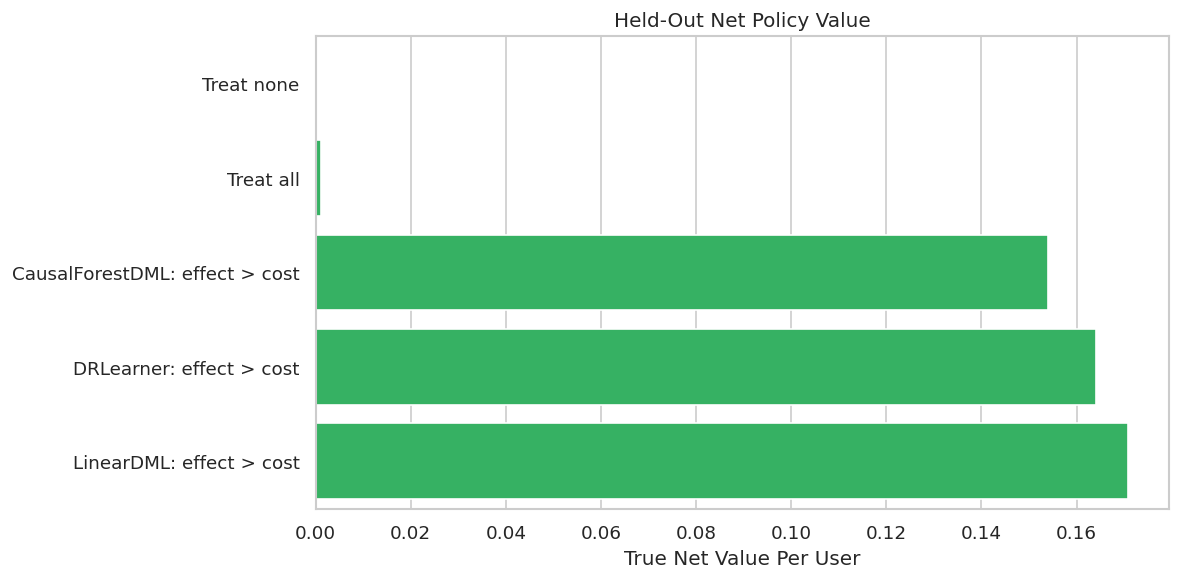

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_policy = policy_summary.sort_values("true_net_value_per_user")
sns.barplot(data=plot_policy, x="true_net_value_per_user", y="policy", color="#22c55e", ax=ax)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Held-Out Net Policy Value")
ax.set_xlabel("True Net Value Per User")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_policy_value.png", dpi=160, bbox_inches="tight")
plt.show()


This is the most decision-facing plot in the lesson. It converts estimated effects into a concrete recommendation and compares that recommendation with obvious alternatives.




#### Budget-Constrained Targeting

A threshold rule is not the only practical choice. If there is a fixed budget, the team may treat only the highest estimated-effect users. The code below evaluates several budget levels.


In [27]:
budget_levels = [0.10, 0.20, 0.30, 0.40, 0.50]
budget_rows = []
for estimator_name in estimators:
    estimated = effect_predictions[estimator_name].to_numpy()
    for budget in budget_levels:
        cutoff = np.quantile(estimated, 1 - budget)
        action = estimated >= cutoff
        budget_rows.append(
            {
                "estimator": estimator_name,
                "budget_share": budget,
                "users_treated": int(action.sum()),
                "true_net_value_per_user": ((true_tau_test - TREATMENT_COST) * action).mean(),
                "mean_true_cate_among_treated": true_tau_test[action].mean(),
                "precision_positive_net": np.mean(true_tau_test[action] > TREATMENT_COST),
            }
        )
budget_curve = pd.DataFrame(budget_rows)
budget_curve.to_csv(TABLE_DIR / f"{CASE_PREFIX}_budget_curve.csv", index=False)
display(budget_curve.head(10))


,estimator,budget_share,users_treated,true_net_value_per_user,mean_true_cate_among_treated,precision_positive_net
0,LinearDML,0.1000,165,0.0786,0.9657,1.0000
1,LinearDML,0.2000,330,0.1222,0.7908,0.9939
2,LinearDML,0.3000,495,0.1507,0.6823,0.9636
3,LinearDML,0.4000,660,0.1671,0.5977,0.9182
4,LinearDML,0.5000,825,0.1715,0.5231,0.8570
5,CausalForestDML,0.1000,165,0.0749,0.9294,1.0000
6,CausalForestDML,0.2000,330,0.1163,0.7613,0.9727
7,CausalForestDML,0.3000,495,0.1396,0.6453,0.9131
8,CausalForestDML,0.4000,660,0.1530,0.5624,0.8682
9,CausalForestDML,0.5000,825,0.1565,0.4930,0.8133


Budget curves show whether an estimator remains useful as the program expands from a small high-confidence group to a broader population.

The decision implication is that estimated gains need to be filtered through uncertainty, cost, support, and operational constraints before becoming actions.
<!-- result-implication-expanded -->




#### Budget Curve Plot

The curve shows net value as the share of treated users increases. Strong policies usually perform best at low budgets and then flatten as lower-benefit users are added.


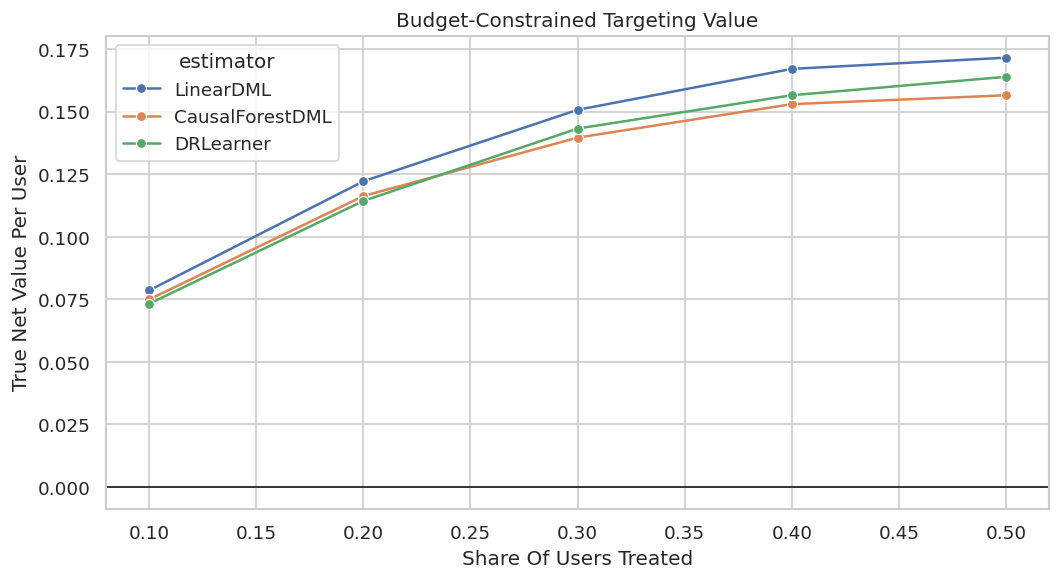

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=budget_curve, x="budget_share", y="true_net_value_per_user", hue="estimator", marker="o", ax=ax)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Budget-Constrained Targeting Value")
ax.set_xlabel("Share Of Users Treated")
ax.set_ylabel("True Net Value Per User")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_budget_curve.png", dpi=160, bbox_inches="tight")
plt.show()


This curve helps choose an operating point. It also avoids implying that a model supports broad rollout when its value is concentrated in a small top segment.


#### Support-Aware Policy Filter

A conservative policy can restrict model-based targeting to users with diagnostic propensities between `0.10` and `0.90`. This avoids acting in regions where observational support is thin.


In [29]:
support_mask = (overlap_frame["estimated_propensity"].to_numpy() >= 0.10) & (overlap_frame["estimated_propensity"].to_numpy() <= 0.90)
support_policy_rows = []
for estimator_name in estimators:
    estimated = effect_predictions[estimator_name].to_numpy()
    standard_action = estimated > TREATMENT_COST
    support_action = standard_action & support_mask
    support_policy_rows.append(
        {
            "estimator": estimator_name,
            "eligible_share": support_mask.mean(),
            "standard_treatment_rate": standard_action.mean(),
            "support_aware_treatment_rate": support_action.mean(),
            "standard_true_net_value": ((true_tau_test - TREATMENT_COST) * standard_action).mean(),
            "support_aware_true_net_value": ((true_tau_test - TREATMENT_COST) * support_action).mean(),
            "users_removed_by_support_filter": int((standard_action & ~support_mask).sum()),
        }
    )
support_policy_summary = pd.DataFrame(support_policy_rows).sort_values("support_aware_true_net_value", ascending=False)
support_policy_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_support_aware_policy_summary.csv", index=False)
display(support_policy_summary)


,estimator,eligible_share,standard_treatment_rate,support_aware_treatment_rate,standard_true_net_value,support_aware_true_net_value,users_removed_by_support_filter
0,LinearDML,0.9988,0.5394,0.5382,0.1709,0.1693,2
2,DRLearner,0.9988,0.5188,0.5176,0.1642,0.1626,2
1,CausalForestDML,0.9988,0.5558,0.5545,0.1540,0.1525,2


The support-aware version is more conservative. It may sacrifice some value in this simulation, but it is often a healthier recommendation when overlap is imperfect.




#### Bootstrap Uncertainty for Policy Value

The next step bootstraps the held-out rows and recomputes policy value. This gives a lightweight uncertainty summary for policy comparisons.


In [30]:
bootstrap_rng = np.random.default_rng(RANDOM_STATE + 99)
N_BOOTSTRAPS = 300
policy_actions = {
    "Treat none": np.zeros(len(test_df), dtype=bool),
    "Treat all": np.ones(len(test_df), dtype=bool),
}
for estimator_name in estimators:
    policy_actions[f"{estimator_name}: effect > cost"] = effect_predictions[estimator_name].to_numpy() > TREATMENT_COST
bootstrap_rows = []
for draw in range(N_BOOTSTRAPS):
    sample_index = bootstrap_rng.choice(len(test_df), size=len(test_df), replace=True)
    for policy_name, action in policy_actions.items():
        value = ((true_tau_test[sample_index] - TREATMENT_COST) * action[sample_index]).mean()
        bootstrap_rows.append({"draw": draw, "policy": policy_name, "true_net_value_per_user": value})
bootstrap_policy = pd.DataFrame(bootstrap_rows)
bootstrap_policy_summary = (
    bootstrap_policy.groupby("policy")
    .agg(
        mean_value=("true_net_value_per_user", "mean"),
        lower_95=("true_net_value_per_user", lambda values: np.quantile(values, 0.025)),
        upper_95=("true_net_value_per_user", lambda values: np.quantile(values, 0.975)),
    )
    .reset_index()
    .sort_values("mean_value", ascending=False)
)
bootstrap_policy.to_csv(TABLE_DIR / f"{CASE_PREFIX}_bootstrap_policy_values.csv", index=False)
bootstrap_policy_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_bootstrap_policy_summary.csv", index=False)
display(bootstrap_policy_summary)


,policy,mean_value,lower_95,upper_95
2,LinearDML: effect > cost,0.1701,0.1560,0.1837
1,DRLearner: effect > cost,0.1635,0.1490,0.1773
0,CausalForestDML: effect > cost,0.1531,0.1386,0.1663
3,Treat all,0.0006,-0.0204,0.0228
4,Treat none,0.0000,0.0000,0.0000


The intervals show whether the apparent policy winner is clearly separated or only slightly ahead. That matters for honest reporting.

The lesson is robustness: a publishable conclusion should not hinge on one arbitrary threshold, one lucky sample split, or one narrow tuning choice.
<!-- result-implication-expanded -->




#### Bootstrap Policy Plot

This plot summarizes uncertainty around net policy value. Wider intervals mean the estimated policy value is more sensitive to which users are in the evaluation sample.


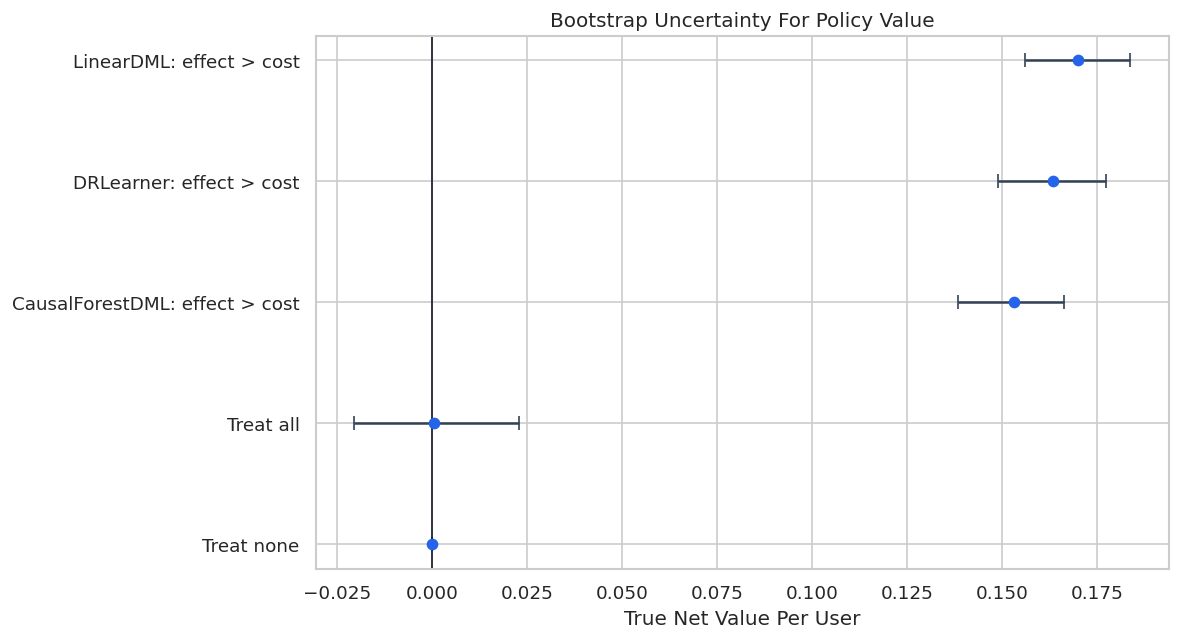

In [31]:
plot_bootstrap = bootstrap_policy_summary.sort_values("mean_value")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.errorbar(
    x=plot_bootstrap["mean_value"],
    y=plot_bootstrap["policy"],
    xerr=[
        plot_bootstrap["mean_value"] - plot_bootstrap["lower_95"],
        plot_bootstrap["upper_95"] - plot_bootstrap["mean_value"],
    ],
    fmt="o",
    color="#2563eb",
    ecolor="#334155",
    capsize=4,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Bootstrap Uncertainty For Policy Value")
ax.set_xlabel("True Net Value Per User")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_bootstrap_policy_intervals.png", dpi=160, bbox_inches="tight")
plt.show()


The final recommendation should consider both point value and uncertainty. If intervals overlap heavily, the safer conclusion is that policies are practically similar until stronger validation is available.





## Reporting and Takeaways

### Report-Ready Summary Table

The final comparison table combines estimation accuracy, targeting value, and runtime. It is designed to be readable outside the lesson.


In [32]:
policy_rows_for_estimators = policy_summary[policy_summary["policy"].str.contains(": effect > cost", regex=False)].copy()
policy_rows_for_estimators["estimator"] = policy_rows_for_estimators["policy"].str.replace(": effect > cost", "", regex=False)
report_summary = (
    benchmark_metrics[["estimator", "estimated_ate", "ate_bias", "cate_rmse", "cate_correlation", "top_20_true_cate_mean", "fit_seconds"]]
    .merge(
        policy_rows_for_estimators[["estimator", "treatment_rate", "true_net_value_per_user", "precision_positive_net"]],
        on="estimator",
    )
    .sort_values("true_net_value_per_user", ascending=False)
)
report_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_report_summary.csv", index=False)
display(report_summary)


,estimator,estimated_ate,ate_bias,cate_rmse,cate_correlation,top_20_true_cate_mean,fit_seconds,treatment_rate,true_net_value_per_user,precision_positive_net
0,LinearDML,0.2309,0.0497,0.2719,0.8948,0.7908,3.0391,0.5394,0.1709,0.8292
1,DRLearner,0.2099,0.0287,0.2720,0.8458,0.7515,3.5732,0.5188,0.1642,0.8236
2,CausalForestDML,0.2147,0.0336,0.3168,0.8173,0.7613,3.6302,0.5558,0.1540,0.7819


This table prevents the conclusion from relying on a single metric. A useful causal model must estimate effects, rank users, and support a decision that creates net value.


### Reporting and Takeaways

A finished analysis should be easy for another careful reader to review. It should state the causal question, target estimand, identification assumptions, main estimate, diagnostics, sensitivity checks, and remaining limitations in plain language. The goal is a clear analytical conclusion supported by the tables and figures already shown in the lesson.


The written summary is short because the lesson already contains the evidence. The recommendation is useful precisely because it pairs a policy result with diagnostics and caveats.




### Final Checklist

The final checklist turns the lesson into a reusable workflow. In real analyses, missing checklist items should be treated as reasons for caution.


| check | what_good_reporting_should_include |
| --- | --- |
| Decision defined | Treatment, outcome, cost, and target population are explicit. |
| Pre-treatment variables separated | Effect modifiers and controls are assigned before fitting. |
| Missingness handled | Imputation is learned from training data only. |
| Confounding diagnosed | Raw gaps, balance, and propensity overlap are reviewed. |
| Nuisance models checked | Treatment and outcome models have held-out diagnostics. |
| Multiple estimators compared | Results are not tied to one estimator by default. |
| Policy value evaluated | CATE estimates are translated into net decision value. |
| Support considered | Weak-overlap regions are handled cautiously. |
| Uncertainty shown | Bootstrap intervals or comparable uncertainty summaries are included. |
| Caveats documented | Assumptions and validation needs are written plainly. |


The checklist closes the loop. A strong EconML workflow is estimator fitting plus design, diagnostics, decision translation, and careful reporting; it is design, diagnostics, estimation, decision translation, and careful reporting.


## What Comes Next

The final lesson in this EconML tutorial sequence should cover common pitfalls, debugging, and reporting. This case study used a clean teaching setup; real applied analyses are more likely to fail through leakage, weak overlap, invalid controls, unstable nuisance models, or overconfident CATE storytelling.
